# Task 5 - EDA and Machine Learning

## 1. Perform exploratory data analysis on the CO2 dataset.

### EDA Before Cleaning

Dataset Shape: (7385, 12)

First 5 Rows:
    Make       Model Vehicle Class  Engine Size(L)  Cylinders Transmission  \
0  ACURA         ILX       COMPACT             2.0          4          AS5   
1  ACURA         ILX       COMPACT             2.4          4           M6   
2  ACURA  ILX HYBRID       COMPACT             1.5          4          AV7   
3  ACURA     MDX 4WD   SUV - SMALL             3.5          6          AS6   
4  ACURA     RDX AWD   SUV - SMALL             3.5          6          AS6   

  Fuel Type  Fuel Consumption City (L/100 km)  \
0         Z                               9.9   
1         Z                              11.2   
2         Z                               6.0   
3         Z                              12.7   
4         Z                              12.1   

   Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
0                              6.7                               8.5   
1                              7.7                 

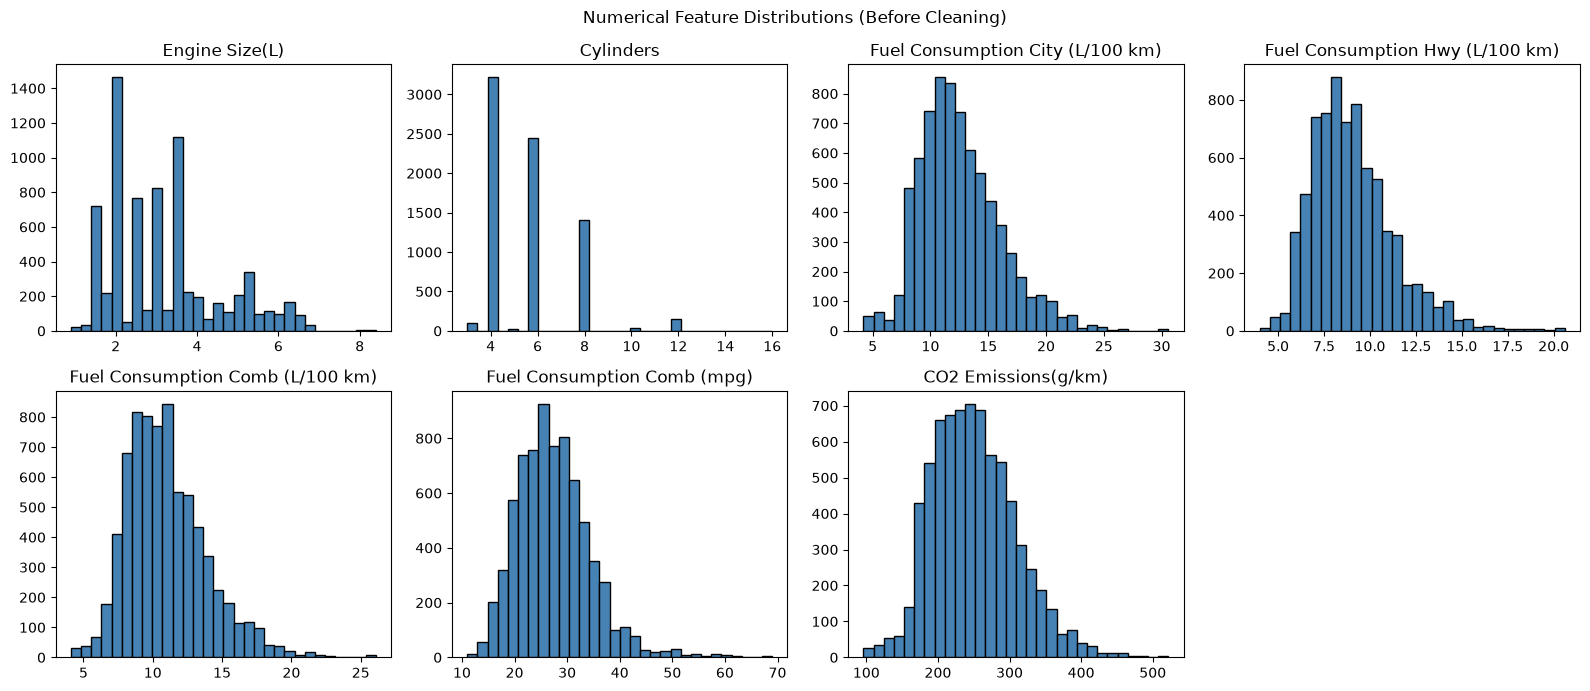

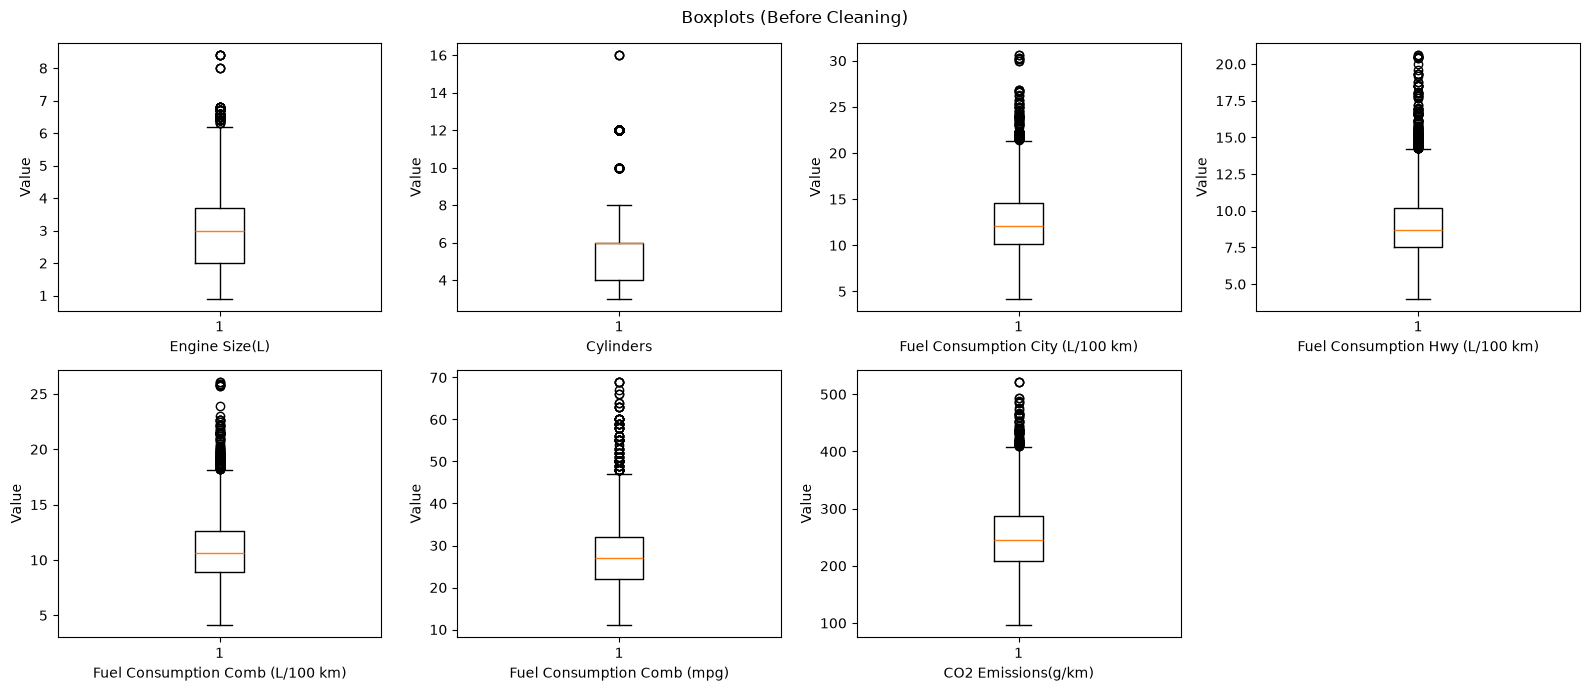

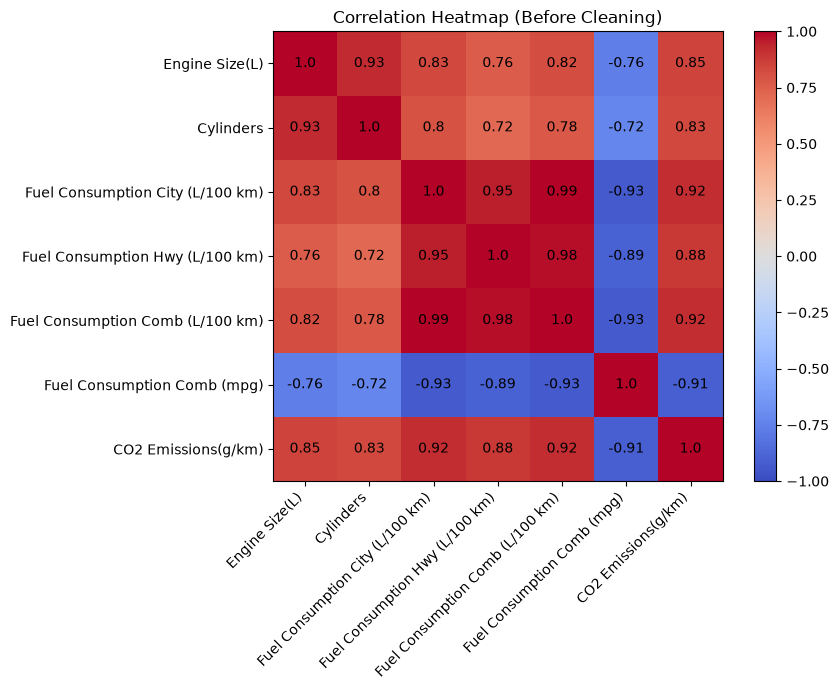

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

co2 = pd.read_csv('co2.csv')

print("Dataset Shape:", co2.shape)
print("\nFirst 5 Rows:")
print(co2.head())
print("\nDataset Info:")
print(co2.info())
print("\nSummary Statistics:")
print(co2.describe())
print("\nMissing Values:")
print(co2.isnull().sum())
print("\nDuplicate Rows Count:", co2.duplicated().sum())

num_cols = co2.select_dtypes(include='number').columns
cat_cols = co2.select_dtypes(exclude='number').columns
target = 'CO2 Emissions(g/km)'

print("\nCategorical Column Unique Values:")
for col in cat_cols:
    print(col, "->", co2[col].nunique(), "unique values")

print("\nIQR Outliers per Column:")

for col in num_cols:
    q1 = co2[col].quantile(0.25)
    q3 = co2[col].quantile(0.75)
    iqr = q3 - q1
    count = ((co2[col] < (q1 - 1.5 * iqr)) | (co2[col] > (q3 + 1.5 * iqr))).sum()
    print(col, ":", count)

print("\nCorrelation with CO2 Emissions:")

print(co2[num_cols].corr()[target].sort_values(ascending=False))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(co2[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)

axes[-1].axis('off')
fig.suptitle('Numerical Feature Distributions (Before Cleaning)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(co2[col])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Value')

axes[-1].axis('off')
fig.suptitle('Boxplots (Before Cleaning)')
plt.tight_layout()
plt.show()

corr = co2[num_cols].corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha='center', va='center')

plt.title('Correlation Heatmap (Before Cleaning)')
plt.tight_layout()
plt.show()



### Cleaning data set into a model ready dataset

In [13]:
text_cols = co2.select_dtypes(include=['object', 'string']).columns
for col in text_cols:
    co2[col] = co2[col].str.strip().str.upper()

co2 = co2.drop_duplicates().dropna()

if 'Fuel Type' in co2.columns:
    co2 = co2[co2['Fuel Type'] != 'N'] #TOO LESS DATA FOR N

co2['Transmission Type'] = co2['Transmission'].str.replace(r'\d+', '', regex=True) #Regular expression, spliiting transmission
co2['Gears'] = co2['Transmission'].str.extract(r'(\d+)', expand=False).astype(float)
co2['Gears'] = co2['Gears'].fillna(co2['Gears'].median())

drop_cols = [
    'Make',
    'Model',
    'Transmission',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (mpg)'
]
co2 = co2.drop(columns=[col for col in drop_cols if col in co2.columns])

co2 = co2.rename(columns={
    'Vehicle Class': 'vehicle_class',
    'Engine Size(L)': 'engine_size',
    'Cylinders': 'cylinders',
    'Fuel Type': 'fuel_type',
    'Fuel Consumption Comb (L/100 km)': 'fuel_comb',
    'CO2 Emissions(g/km)': 'co2',
    'Transmission Type': 'transmission_type',
    'Gears': 'gears'
})

outlier_cols = ['engine_size', 'fuel_comb', 'co2']
keep_mask = pd.Series(True, index=co2.index)
for col in outlier_cols:
    q1 = co2[col].quantile(0.25)
    q3 = co2[col].quantile(0.75)
    iqr = q3 - q1
    keep_mask = keep_mask & (co2[col] >= q1 - 1.5 * iqr) & (co2[col] <= q3 + 1.5 * iqr)

co2 = co2[keep_mask]

co2['high_emission'] = np.where(co2['co2'] > co2['co2'].median(), 1, 0)

co2 = pd.get_dummies(co2, columns=['vehicle_class', 'fuel_type', 'transmission_type'], drop_first=True, dtype=int)

scale_cols = ['engine_size', 'cylinders', 'fuel_comb', 'gears']
for col in scale_cols:
    co2[col] = (co2[col] - co2[col].mean()) / co2[col].std()

co2 = co2.reset_index(drop=True)
co2.to_csv('co2cleaned.csv', index=False)

### EDA After Cleaning


Final Cleaned Shape: (5801, 28)
Missing Values in Cleaned Data: 0

Cleaned Head:
   engine_size  cylinders  fuel_comb  co2     gears  high_emission  \
0    -0.844865  -0.884620  -0.884574  196 -1.532323              0   
1    -0.532870  -0.884620  -0.459430  221 -0.699005              0   
2    -1.234860  -0.884620  -1.889461  136  0.134314              0   
3     0.325119   0.287532   0.120312  255 -0.699005              1   
4     0.325119   0.287532  -0.072935  244 -0.699005              0   

   vehicle_class_FULL-SIZE  vehicle_class_MID-SIZE  vehicle_class_MINICOMPACT  \
0                        0                       0                          0   
1                        0                       0                          0   
2                        0                       0                          0   
3                        0                       0                          0   
4                        0                       0                          0   

   vehicle

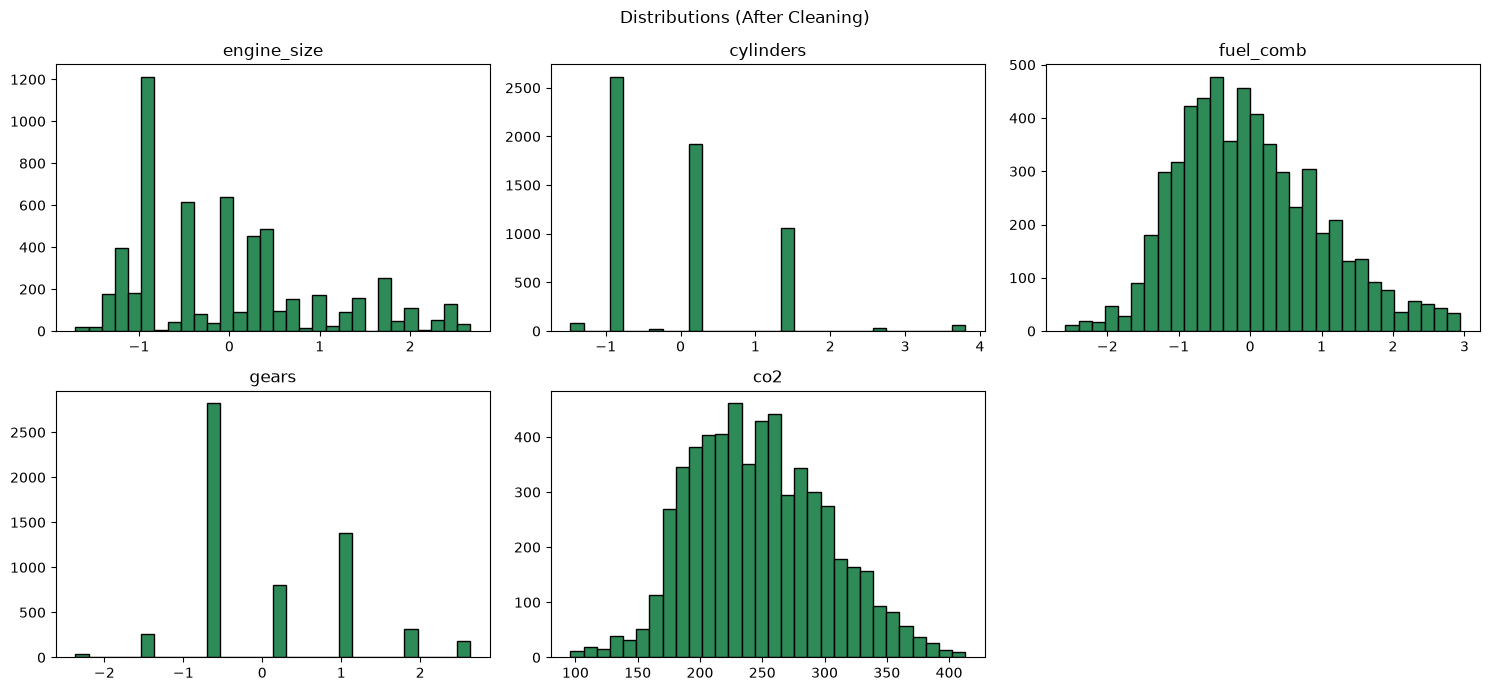

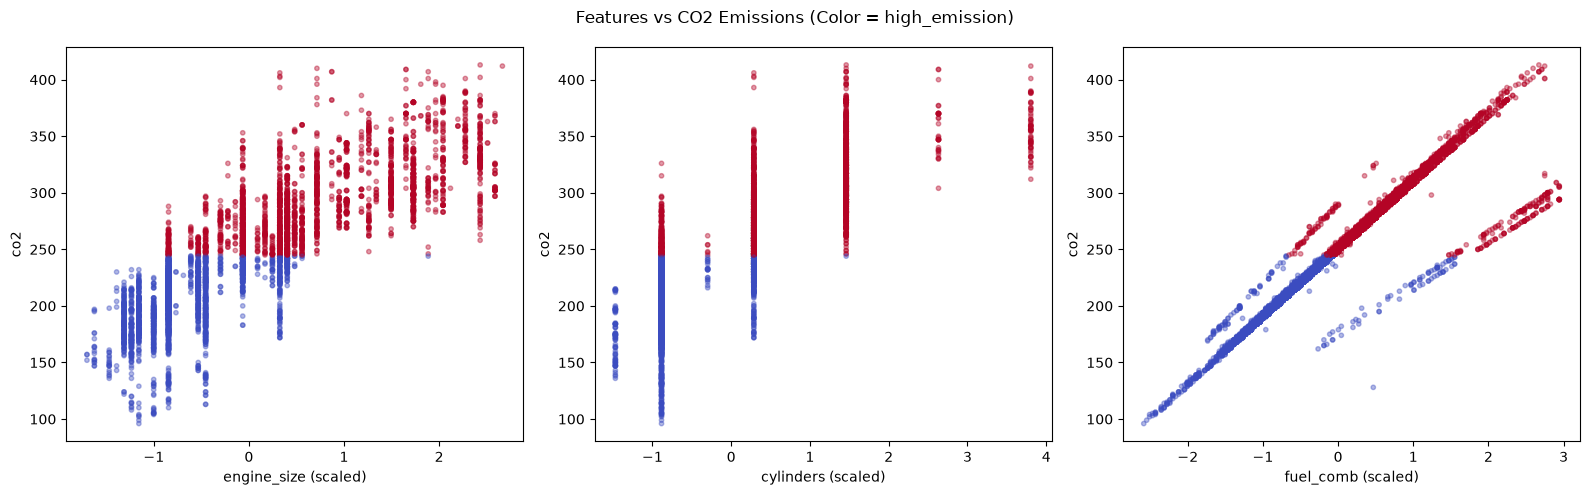

Text(0, 0.5, 'Count')

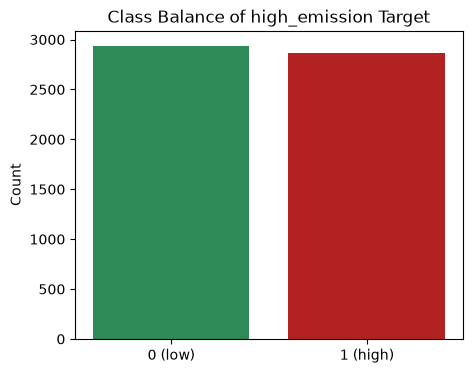

In [14]:

print("\nFinal Cleaned Shape:", co2.shape)
print("Missing Values in Cleaned Data:", co2.isnull().sum().sum())
print("\nCleaned Head:")
print(co2.head())

plot_cols = ['engine_size', 'cylinders', 'fuel_comb', 'gears', 'co2']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    axes[i].hist(co2[col], bins=30, color='seagreen', edgecolor='black')
    axes[i].set_title(col)
axes[-1].axis('off')
fig.suptitle('Distributions (After Cleaning)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['engine_size', 'cylinders', 'fuel_comb']):
    axes[i].scatter(co2[col], co2['co2'], c=co2['high_emission'], cmap='coolwarm', alpha=0.4, s=10)
    axes[i].set_xlabel(col + ' (scaled)')
    axes[i].set_ylabel('co2')
fig.suptitle('Features vs CO2 Emissions (Color = high_emission)')
plt.tight_layout()
plt.show()

counts = co2['high_emission'].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(['0 (low)', '1 (high)'], counts.values, color=['seagreen', 'firebrick'])
plt.title('Class Balance of high_emission Target')
plt.ylabel('Count')

## 2. Implementing linear regression on the CO2 dataset.

Iteration 0 Cost: 31299.3942
Iteration 100 Cost: 4147.7576
Iteration 200 Cost: 646.8013
Iteration 300 Cost: 162.8222
Iteration 400 Cost: 87.2261
Iteration 500 Cost: 68.7529
Iteration 600 Cost: 59.493
Iteration 700 Cost: 52.6283
Iteration 800 Cost: 47.0015
Iteration 900 Cost: 42.2813

--- Model Evaluation ---
Train MSE: 76.6476
Test MSE: 77.5013

Learned Parameters:
Bias (b): 247.167
                               Feature     Weight
                           engine_size   5.608307
                             cylinders   5.287815
                             fuel_comb  37.207540
                                 gears   0.263770
                         high_emission   6.581091
               vehicle_class_FULL-SIZE   0.427344
                vehicle_class_MID-SIZE  -0.188393
             vehicle_class_MINICOMPACT  -0.599033
                 vehicle_class_MINIVAN   0.467711
    vehicle_class_PICKUP TRUCK - SMALL   2.422395
 vehicle_class_PICKUP TRUCK - STANDARD   2.737373
 vehicle_class

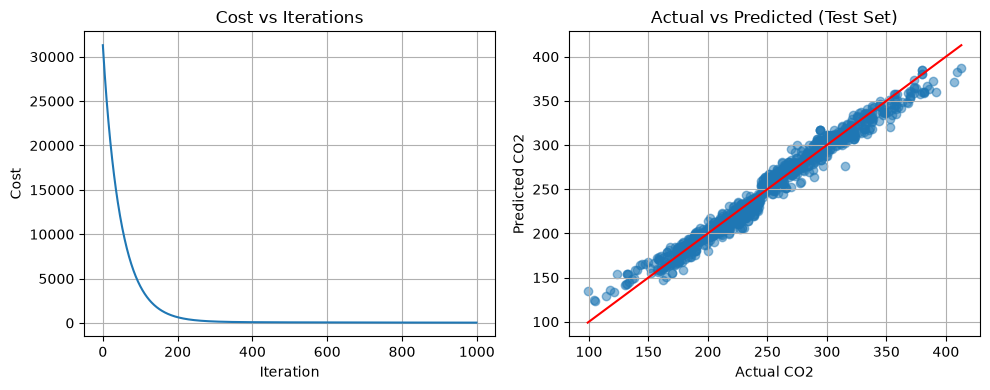

In [ ]:
co2LR = pd.read_csv("co2cleaned.csv")

X = co2LR.drop(columns=["co2"]).values.astype(float)
y = co2LR["co2"].values.astype(float)

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean) / X_std

np.random.seed(1)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

def predict(X, w, b):
    return np.dot(X, w) + b

def compute_cost(X, y, w, b):
    m = X.shape[0]
    errors = predict(X, w, b) - y
    return np.sum(errors ** 2) / (2 * m)

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    errors = predict(X, w, b) - y
    dj_dw = np.dot(X.T, errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, num_iters):
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))
        if i % 100 == 0:
            print("Iteration", i, "Cost:", round(cost_history[-1], 4))
    return w, b, cost_history

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

w_init = np.zeros(X_train.shape[1])
b_init = 0.0
alpha = 0.01
num_iters = 1000

w, b, cost_history = gradient_descent(X_train, y_train, w_init, b_init, alpha, num_iters)

train_pred = predict(X_train, w, b)
test_pred = predict(X_test, w, b)

print("\n--- Model Evaluation ---")
print("Train MSE:", round(mse(y_train, train_pred), 4))
print("Test MSE:", round(mse(y_test, test_pred), 4))

feature_names = co2LR.drop(columns=["co2"]).columns
weights_co2LR = pd.DataFrame({"Feature": feature_names, "Weight": w})
print("\nLearned Parameters:")
print("Bias (b):", round(b, 4))
print(weights_co2LR.to_string(index=False))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
low = min(y_test.min(), test_pred.min())
high = max(y_test.max(), test_pred.max())
plt.plot([low, high], [low, high], color="red")
plt.xlabel("Actual CO2")
plt.ylabel("Predicted CO2")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. Implementing logistic regression on the CO2 dataset.

Iteration 0 Cost: 0.644
Iteration 100 Cost: 0.2212
Iteration 200 Cost: 0.1875
Iteration 300 Cost: 0.1709
Iteration 400 Cost: 0.1601
Iteration 500 Cost: 0.1522
Iteration 600 Cost: 0.1459
Iteration 700 Cost: 0.1407
Iteration 800 Cost: 0.1362
Iteration 900 Cost: 0.1324

--- Model Evaluation ---
Train Accuracy: 0.9526
Test Accuracy: 0.95

Learned Parameters:
Bias (b): 0.5035
                               Feature    Weight
                           engine_size  1.149473
                             cylinders  1.236660
                             fuel_comb  3.245911
                                 gears -0.134197
               vehicle_class_FULL-SIZE  0.014641
                vehicle_class_MID-SIZE -0.107594
             vehicle_class_MINICOMPACT -0.020258
                 vehicle_class_MINIVAN  0.118305
    vehicle_class_PICKUP TRUCK - SMALL  0.606329
 vehicle_class_PICKUP TRUCK - STANDARD  0.801718
 vehicle_class_SPECIAL PURPOSE VEHICLE  0.163965
vehicle_class_STATION WAGON - MID-SIZE

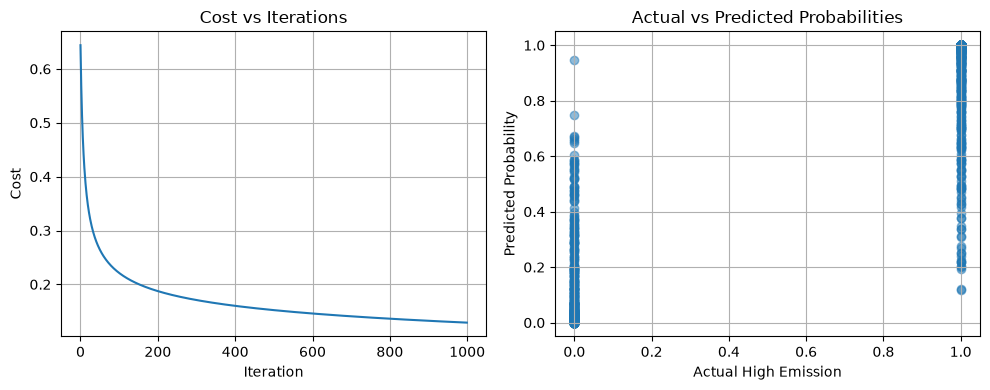

In [16]:
co2LogR = pd.read_csv("co2cleaned.csv")

X = co2LogR.drop(columns=["co2", "high_emission"]).values.astype(float)
y = co2LogR["high_emission"].values.astype(float)

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean) / X_std

np.random.seed(1)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_prob(X, w, b):
    return sigmoid(np.dot(X, w) + b)

def predict(X, w, b):
    return (predict_prob(X, w, b) >= 0.5).astype(int)

def compute_cost(X, y, w, b):
    m = X.shape[0]
    p = predict_prob(X, w, b)
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)) / m

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    errors = predict_prob(X, w, b) - y
    dj_dw = np.dot(X.T, errors) / m
    dj_db = np.sum(errors) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, num_iters):
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))
        if i % 100 == 0:
            print("Iteration", i, "Cost:", round(cost_history[-1], 4))
    return w, b, cost_history

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

w_init = np.zeros(X_train.shape[1])
b_init = 0.0
alpha = 0.1
num_iters = 1000

w, b, cost_history = gradient_descent(X_train, y_train, w_init, b_init, alpha, num_iters)

train_pred = predict(X_train, w, b)
test_pred = predict(X_test, w, b)
test_probs = predict_prob(X_test, w, b)

print("\n--- Model Evaluation ---")
print("Train Accuracy:", round(accuracy(y_train, train_pred), 4))
print("Test Accuracy:", round(accuracy(y_test, test_pred), 4))

feature_names = co2LogR.drop(columns=["co2", "high_emission"]).columns
weights_co2LogR = pd.DataFrame({"Feature": feature_names, "Weight": w})
print("\nLearned Parameters:")
print("Bias (b):", round(b, 4))
print(weights_co2LogR.to_string(index=False))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test, test_probs, alpha=0.5)
plt.xlabel("Actual High Emission")
plt.ylabel("Predicted Probability")
plt.title("Actual vs Predicted Probabilities")
plt.grid(True)

plt.tight_layout()
plt.show()